<a href="https://colab.research.google.com/github/CorgiFan/Pytorch_Practice/blob/main/Torch_Movement_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pynwb dandi --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.4/398.4 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.6/118.6 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.3/362.3 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131

In [6]:
from dandi.dandiapi import DandiAPIClient

client = DandiAPIClient()

# Search for dandisets related to Allen Brain Observatory calcium imaging
for ds in client.get_dandisets():
    metadata = ds.get_raw_metadata()
    name = metadata.get('name', '')
    if 'allen' in name.lower() or 'visual coding' in name.lower() or 'ophys' in name.lower():
        print(ds.identifier, "-", name)

000005 - Electrophysiology data from thalamic and cortical neurons during somatosensation
000021 - Allen Institute - Visual Coding - Neuropixels (Brain Observatory 1.1 Stimulus Set)
000022 - Allen Institute - Visual Coding - Neuropixels (Functional Connectivity Stimulus Set)
000030 - Allen Brain Observatory Neuropixels recording
000036 - Allen Institute Openscope - Measuring Stimulus-Evoked Neurophysiological Differentiation in Distinct Populations of Neurons in Mouse Visual Cortex
000037 - Allen Institute Openscope - Responses to inconsistent stimuli in somata and distal apical dendrites in primary visual cortex
000039 - Allen Institute – Contrast tuning in mouse visual cortex with calcium imaging
000042 - Allen Institute Openscope - Meaningful project  - Full movies
000049 - Allen Institute – TF x SF tuning in mouse visual cortex with calcium imaging
000050 - Allen Institute - Run Tuning in the Mouse Visual Cortex
000066 - Allen Mouse Common Coordinate Framework - Average Brain Templ

In [2]:
from dandi.dandiapi import DandiAPIClient

client = DandiAPIClient()
dandiset = client.get_dandiset("000728")
assets = list(dandiset.get_assets())
print(f"Found {len(assets)} files")
print(assets[0].path)

asset = assets[0]
asset.download("session.nwb")

Found 3036 files
sub-691657859/sub-691657859_ses-712919679-StimB_ophys.nwb


INFO:dandi:Asset c2d7ca42-ec90-4d96-8a9f-40b9f390aafe (3432368 bytes in 1 chunks starting from 0) successfully downloaded from https://api.dandiarchive.org/api/assets/c2d7ca42-ec90-4d96-8a9f-40b9f390aafe/download/


In [3]:
asset = assets[0]  # pick one session
asset.download("session.nwb")

INFO:dandi:Asset c2d7ca42-ec90-4d96-8a9f-40b9f390aafe (3432368 bytes in 1 chunks starting from 0) successfully downloaded from https://api.dandiarchive.org/api/assets/c2d7ca42-ec90-4d96-8a9f-40b9f390aafe/download/


In [4]:
from pynwb import NWBHDF5IO

io = NWBHDF5IO("session.nwb", mode="r")
nwbfile = io.read()

print(nwbfile.processing.keys())
for name, module in nwbfile.processing.items():
    print(name, "->", list(module.data_interfaces.keys()))

print(nwbfile.stimulus.keys())

dict_keys([])
dict_keys([])


In [5]:
print(nwbfile.processing.keys())
for name, module in nwbfile.processing.items():
    print(name, "->", list(module.data_interfaces.keys()))

print(nwbfile.stimulus.keys())
print(nwbfile.intervals.keys() if nwbfile.intervals else "no intervals table")

dict_keys([])
dict_keys([])
no intervals table


In [6]:
for i, asset in enumerate(assets[:20]):
    print(i, asset.path, "-", round(asset.size / (1024**2)), "MB")

0 sub-691657859/sub-691657859_ses-712919679-StimB_ophys.nwb - 3 MB
1 sub-501800590/sub-501800590_ses-509522931-StimC_ophys.nwb - 36598 MB
2 sub-572569275/sub-572569275_ses-591563201-StimB_ophys.nwb - 35128 MB
3 sub-646205980/sub-646205980_ses-657224241-StimA_ophys.nwb - 33576 MB
4 sub-647086913/sub-647086913_ses-657082055-StimA_ophys.nwb - 40182 MB
5 sub-558793503/sub-558793503_ses-569810774-StimB_ophys.nwb - 33174 MB
6 sub-577808199/sub-577808199_ses-593373156-StimA_ophys.nwb - 33006 MB
7 sub-576746148/sub-576746148_ses-593389688-StimB_ophys.nwb - 37072 MB
8 sub-581739586/sub-581739586_ses-593438037-StimC2_ophys.nwb - 50741 MB
9 sub-491604967/sub-491604967_ses-501567645-StimA_behavior+image+ophys.nwb - 329 MB
10 sub-491604967/sub-491604967_ses-501490610-StimB_behavior+image+ophys.nwb - 298 MB
11 sub-491604967/sub-491604967_ses-496908818-StimB_behavior+image+ophys.nwb - 435 MB
12 sub-491604967/sub-491604967_ses-501724959-StimA_behavior+image+ophys.nwb - 507 MB
13 sub-491604983/sub-4916

In [7]:
asset = assets[15]
print(asset.path, asset.size / (1024**2), "MB")

asset.download("session.nwb")

import os
print(os.path.getsize("session.nwb") / (1024**2), "MB downloaded")
print(asset.size / (1024**2), "MB expected")

sub-491604983/sub-491604983_ses-501004031-StimA_behavior+image+ophys.nwb 385.9442186355591 MB


INFO:dandi:Asset 4dd6a25b-6b85-454f-b327-fa3c340bcb5d (404691845 bytes in 49 chunks starting from 0) successfully downloaded from https://api.dandiarchive.org/api/assets/4dd6a25b-6b85-454f-b327-fa3c340bcb5d/download/


385.9442186355591 MB downloaded
385.9442186355591 MB expected


In [10]:
!pip install remfile --quiet

import remfile
import h5py
from pynwb import NWBHDF5IO

s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)
print(s3_url)

file = remfile.File(s3_url)
h5_file = h5py.File(file, 'r')
io = NWBHDF5IO(file=h5_file, mode='r', load_namespaces=True)
nwbfile = io.read()

print("Processing modules:", nwbfile.processing.keys())
for name, module in nwbfile.processing.items():
    print(name, "->", list(module.data_interfaces.keys()))

print("Stimulus:", nwbfile.stimulus.keys())
print("Intervals:", nwbfile.intervals.keys() if nwbfile.intervals else "no intervals table")

https://dandiarchive.s3.amazonaws.com/blobs/dd0/8cf/dd08cf67-d1c5-4bfc-bcd7-bc67de537b11
Processing modules: dict_keys(['behavior', 'ophys'])
behavior -> ['BehavioralTimeSeries', 'CompassDirection', 'EyeTracking', 'PupilTracking']
ophys -> ['DfOverF', 'Fluorescence', 'ImageSegmentation', 'SummaryImages', 'ContaminationRatios']
Stimulus: dict_keys(['natural_movie_one_stimulus', 'natural_movie_three_stimulus', 'drifting_gratings', 'spontaneous_stimulus'])
Intervals: dict_keys(['epochs'])


In [11]:
# Get the DfOverF traces
ophys_module = nwbfile.processing['ophys']
dff = ophys_module.data_interfaces['DfOverF']

# DfOverF usually contains one or more RoiResponseSeries — inspect what's there
print(dff.roi_response_series.keys())

dict_keys(['DfOverF'])


In [12]:
drifting_gratings = nwbfile.stimulus['drifting_gratings']
print(type(drifting_gratings))
print(drifting_gratings)

<class 'pynwb.epoch.TimeIntervals'>
drifting_gratings pynwb.epoch.TimeIntervals at 0x133850194860256
Fields:
  colnames: ['start_time' 'stop_time' 'orientation_in_degrees'
 'spatial_frequency_in_cycles_per_degree' 'temporal_frequency_in_hz'
 'is_blank_sweep']
  columns: (
    start_time <class 'hdmf.common.table.VectorData'>,
    stop_time <class 'hdmf.common.table.VectorData'>,
    orientation_in_degrees <class 'hdmf.common.table.VectorData'>,
    spatial_frequency_in_cycles_per_degree <class 'hdmf.common.table.VectorData'>,
    temporal_frequency_in_hz <class 'hdmf.common.table.VectorData'>,
    is_blank_sweep <class 'hdmf.common.table.VectorData'>
  )
  description: Parameterizations of full field drifting sinusoidal grating at a single spatial contrast (80%). Direction of motion is to the orientation of the grating.
  id: id <class 'hdmf.common.table.ElementIdentifiers'>



In [13]:
stim_table = drifting_gratings.to_dataframe()
print(stim_table.shape)
print(stim_table.head())
print(stim_table['orientation_in_degrees'].unique())

(628, 6)
    start_time  stop_time  orientation_in_degrees  \
id                                                  
0     30.54295   32.54295                    90.0   
1     33.53553   35.53553                    45.0   
2     36.52812   38.52812                   180.0   
3     39.52071   41.52071                    90.0   
4     42.54655   44.54655                   225.0   

    spatial_frequency_in_cycles_per_degree  temporal_frequency_in_hz  \
id                                                                     
0                                     0.04                       8.0   
1                                     0.04                       4.0   
2                                     0.04                       4.0   
3                                     0.04                       2.0   
4                                     0.04                       4.0   

    is_blank_sweep  
id                  
0            False  
1            False  
2            False  
3        

In [14]:
print(stim_table['is_blank_sweep'].value_counts())

real_trials = stim_table[stim_table['is_blank_sweep'] == False]
print("Real trials:", len(real_trials))
print("Per orientation:", real_trials['orientation_in_degrees'].value_counts())

is_blank_sweep
False    598
True      30
Name: count, dtype: int64
Real trials: 598
Per orientation: orientation_in_degrees
90.0     75
45.0     75
225.0    75
315.0    75
270.0    75
135.0    75
180.0    74
0.0      74
Name: count, dtype: int64


In [15]:
dff = nwbfile.processing['ophys'].data_interfaces['DfOverF']
print(dff.roi_response_series.keys())

dict_keys(['DfOverF'])


In [16]:
response_series = dff.roi_response_series['DfOverF']
traces = response_series.data[:]
timestamps = response_series.timestamps[:]

print("Traces shape:", traces.shape)
print("Timestamps shape:", timestamps.shape)
print("First few timestamps:", timestamps[:5])

Traces shape: (115473, 89)
Timestamps shape: (115473,)
First few timestamps: [5.73787 5.77112 5.80437 5.83762 5.87087]


In [17]:
import numpy as np

real_trials_df = stim_table[stim_table['is_blank_sweep'] == False].reset_index(drop=True)

pre_seconds = 0.5   # time before stimulus onset to include
post_seconds = 1.0  # time after onset to include

trial_snippets = []
labels = []

for _, row in real_trials_df.iterrows():
    onset_time = row['start_time']

    # Find the index in `timestamps` closest to (onset_time - pre_seconds)
    # and (onset_time + post_seconds)
    start_idx = np.searchsorted(timestamps, onset_time - pre_seconds)
    end_idx = np.searchsorted(timestamps, onset_time + post_seconds)

    # Skip trials too close to the start/end of the recording
    if start_idx < 0 or end_idx > len(timestamps):
        continue

    snippet = traces[start_idx:end_idx, :]  # shape: (timepoints_in_window, neurons)
    trial_snippets.append(snippet)
    labels.append(row['orientation_in_degrees'])

In [18]:
# Find the minimum window length across all trials, and trim everything to match
min_len = min(s.shape[0] for s in trial_snippets)
trial_snippets = [s[:min_len, :] for s in trial_snippets]

trials = np.stack(trial_snippets)   # shape: (num_trials, timepoints, neurons)
labels = np.array(labels)

print("Trials shape:", trials.shape)
print("Unique labels:", np.unique(labels))

Trials shape: (598, 46, 89)
Unique labels: [  0.  45.  90. 135. 180. 225. 270. 315.]


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Collapse the time dimension — average each neuron's activity across the trial window
trial_avg = trials.mean(axis=1)  # shape: (598, 89) — trials x neurons

le = LabelEncoder()
y = le.fit_transform(labels)  # converts 0/45/90.../315 into 0-7 integer classes

X_train, X_test, y_train, y_test = train_test_split(
    trial_avg, y, test_size=0.2, random_state=42, stratify=y
)

baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train, y_train)
baseline_acc = baseline.score(X_test, y_test)
print(f"Baseline accuracy: {baseline_acc:.3f}")
print(f"Chance level: {1/8:.3f}")  # 8 classes, so random guessing = 12.5%

Baseline accuracy: 0.183
Chance level: 0.125


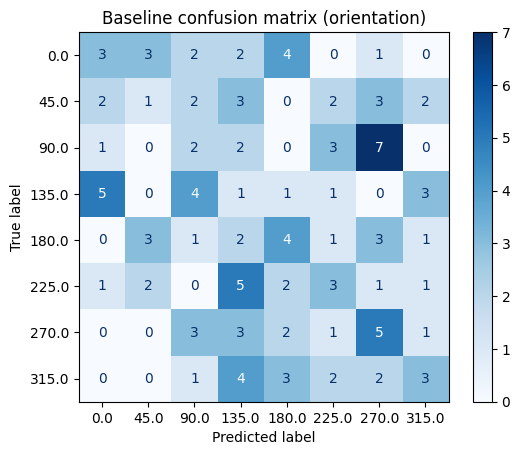

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

preds = baseline.predict(X_test)
cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("Baseline confusion matrix (orientation)")
plt.show()

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np

In [22]:
class CalciumDataset(Dataset):
    def __init__(self, X, y):
        # X shape: (num_trials, timepoints, neurons) — already matches what you have
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

full_dataset = CalciumDataset(trials, y)  # using `y` from your LabelEncoder step, not raw `labels`

print(len(full_dataset))

598


In [23]:
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

train_dataset, test_dataset = random_split(
    full_dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)  # reproducible split
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Train trials: {len(train_dataset)}, Test trials: {len(test_dataset)}")

Train trials: 478, Test trials: 120


In [24]:
class CalciumRNN(nn.Module):
    def __init__(self, num_neurons, hidden_size=64, num_classes=8):
        super().__init__()
        self.gru = nn.GRU(input_size=num_neurons, hidden_size=hidden_size, batch_first=True)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        out, h_n = self.gru(x)       # out: activity at every timestep, h_n: final hidden state
        final_hidden = h_n[-1]        # shape: (batch, hidden_size)
        return self.classifier(final_hidden)

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

num_neurons = trials.shape[2]   # 89
num_classes = len(np.unique(y)) # 8

model = CalciumRNN(num_neurons=num_neurons, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

Using device: cuda


In [26]:
epochs = 50
best_accuracy = 0.0
patience = 10
epochs_no_improve = 0

train_losses = []
val_accuracies = []

for epoch in range(epochs):

    # ---------------- Training phase ----------------
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_loss)

    # ---------------- Validation phase ----------------
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            predictions = torch.argmax(outputs, dim=1)

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    accuracy = correct / total
    val_accuracies.append(accuracy)

    scheduler.step(accuracy)

    print(f"Epoch {epoch+1}/{epochs}: Train Loss = {epoch_loss:.4f}, Val Accuracy = {accuracy:.4f}")

    # ---------------- Checkpointing + early stopping ----------------
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_calcium_model.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            break

print(f"\nBest RNN accuracy: {best_accuracy:.4f}")
print(f"Baseline accuracy: {baseline_acc:.4f}")
print(f"Chance level: {1/8:.4f}")

Epoch 1/50: Train Loss = 2.0880, Val Accuracy = 0.1250
Epoch 2/50: Train Loss = 2.0749, Val Accuracy = 0.1250
Epoch 3/50: Train Loss = 2.0558, Val Accuracy = 0.1583
Epoch 4/50: Train Loss = 2.0104, Val Accuracy = 0.1833
Epoch 5/50: Train Loss = 1.9449, Val Accuracy = 0.2083
Epoch 6/50: Train Loss = 1.8840, Val Accuracy = 0.1833
Epoch 7/50: Train Loss = 1.8339, Val Accuracy = 0.1917
Epoch 8/50: Train Loss = 1.7550, Val Accuracy = 0.2417
Epoch 9/50: Train Loss = 1.7118, Val Accuracy = 0.2333
Epoch 10/50: Train Loss = 1.6719, Val Accuracy = 0.2250
Epoch 11/50: Train Loss = 1.6160, Val Accuracy = 0.3417
Epoch 12/50: Train Loss = 1.6066, Val Accuracy = 0.3000
Epoch 13/50: Train Loss = 1.5411, Val Accuracy = 0.2750
Epoch 14/50: Train Loss = 1.5014, Val Accuracy = 0.2667
Epoch 15/50: Train Loss = 1.5049, Val Accuracy = 0.2667
Epoch 16/50: Train Loss = 1.4219, Val Accuracy = 0.3750
Epoch 17/50: Train Loss = 1.4025, Val Accuracy = 0.3417
Epoch 18/50: Train Loss = 1.3461, Val Accuracy = 0.3750
E

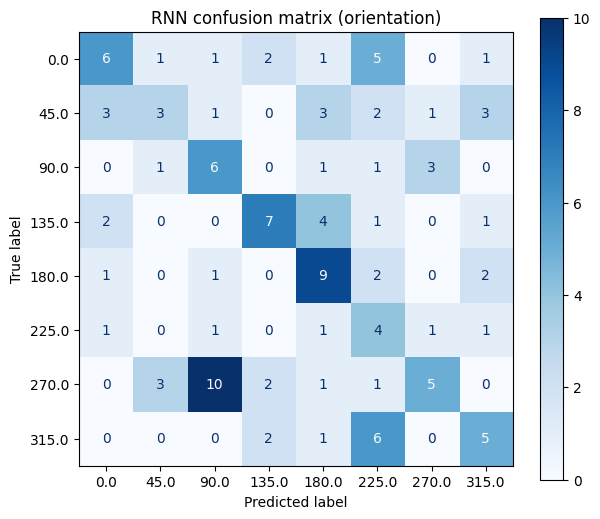

              precision    recall  f1-score   support

         0.0       0.46      0.35      0.40        17
        45.0       0.38      0.19      0.25        16
        90.0       0.30      0.50      0.38        12
       135.0       0.54      0.47      0.50        15
       180.0       0.43      0.60      0.50        15
       225.0       0.18      0.44      0.26         9
       270.0       0.50      0.23      0.31        22
       315.0       0.38      0.36      0.37        14

    accuracy                           0.38       120
   macro avg       0.40      0.39      0.37       120
weighted avg       0.42      0.38      0.37       120



In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Load the best checkpoint
model.load_state_dict(torch.load("best_calcium_model.pth"))
model.to(device)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        predictions = torch.argmax(outputs, dim=1)

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(y_batch.numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title("RNN confusion matrix (orientation)")
plt.savefig("rnn_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(all_labels, all_preds, target_names=[str(c) for c in le.classes_]))